<div style="border:solid green 2px; padding: 20px"> <h1 style="color:green; margin-bottom:20px">Reviewers comment v1</h1>

Hello George!

I'm happy to review your project today 🙌

My name is **Justino Imbert** ([this](https://hub.tripleten.com/u/125e88ae) is my Hub profile) and today I'll be reviewing your project!


You can find my comments under the heading **«Review»**. I will categorize my comments in green, blue or red boxes like this:

<div class="alert alert-success">
    <b>Success:</b> if everything is done successfully
</div>
<div class="alert alert-warning">
    <b>Remarks:</b> if I can give some recommendations or ways to improve the project
</div>
<div class="alert alert-danger">
    <b>Needs fixing:</b> if the block requires some corrections. Work cant be accepted with the red comments
</div>

Please dont remove my comments :) If you have any questions dont hesitate to respond to my comments in a different section. 
<div class="alert alert-info"> <b>Student comments:</b> For example like this</div>   

<div class="alert alert-block alert-info">
<b>Reviewer's comment v1:</b> </a>

You are doing a great job in this project! I left you some comments for you to address before I can approve it!

Looking forward to reviewing your next submission! Best of luck!

    
</div>

<div style="border:solid green 2px; padding: 20px">
<b>Reviewer's comment v2:</b>

    
<b>Overall Feedback</b>
    
Hello George,

My name is **Gerardo Flores** and you can find me on the HUB as https://hub.tripleten.com/u/1949959f
    
You’ve submitted another project—great work! Your commitment to pushing through the challenges of this program is admirable.

After reviewing your submission, it is approved.
    
   
You can find my more detailed notes within your project notebook in the `Reviewer's comment v2:` section.


If you find yourself uncertain or in need of further insights, never hesitate to consult with your tutor or ask your questions here. We are here to guide and assist you.

# Phase 1 - Load and Prepare Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from copy import deepcopy
from sklearn.base import clone
from sklearn.utils import shuffle, resample
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, \
    StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, confusion_matrix, average_precision_score, roc_curve, auc

## Step 1.1 - Load and Inspect Data
    Load the data and take a long, suspicious look at it.

In [2]:
# Create universal variables
RNG=12345
dtc = DecisionTreeClassifier(random_state=RNG)
rfc = RandomForestClassifier(random_state=RNG)
etc = ExtraTreesClassifier(random_state=RNG)
scoring='f1'

data = pd.read_csv('/datasets/Churn.csv')

unique_countries = data['Geography'].unique()

print(data.info())
print(data.head(10))
print(f"Unique countries in the dataset: {unique_countries}")

# Examine missing values in 'Tenure' column
bins = [0, 25, 35, 45, 55, 65, 75, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']
data['AgeGroup'] = pd.cut(data['Age'], bins=bins, labels=labels, right=True)
data.groupby('AgeGroup')['Tenure'].describe()

missing_pct = data.groupby('AgeGroup')['Tenure'].apply(lambda x: round(x.isna().mean() * 100, 3))
mean_tenure = data.groupby('AgeGroup')['Tenure'].mean()
replacement_map = (1 - missing_pct /100) * mean_tenure
print(f"Percent per Age Group Missing: {missing_pct}")
print(f'Replace Missing: {replacement_map}')

def fill_tenure(row):
    if pd.isna(row['Tenure']):
        return replacement_map[row['AgeGroup']]
    else:
        return row['Tenure']

data['Tenure'] = data.apply(fill_tenure, axis=1)

print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB
None
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1   

This data was not to bad with missing data. The only area I saw missing values was in the 'Tenure' column. So I grouped all the ages together and deteremined the percentage of missing data from each group. I then took that percentage and subtracted it from 1 and multiplied it by the 'Mean Tenure' for each age group. Thus providing a decent approximation of those customer's tenure.

## Step 1.2 - Which Features are Useful?
    Decide which features are useful for modeling and which are fluff.

After evaluation of the data structure this is what I have found about the features:
1. Numerical - <font color="blue"><ins>**Useful**</ins></font>
    - CreditScore - Needs to be scaled
    - Age - Needs to be scaled
    - Tenure - Needs to be scaled
    - Balance - Needs to be scaled
    - EstimatedSalary - Needs to be scaled
    - NumOfProducts

2. Categorical - <font color="blue"><ins>**Useful**</ins></font>
    - Geography - 3 unique values
    - Gender - Binary Classification
    - HasCrCard - Binary Classification
    - IsActiveMember - Binary Classification

3. Fluff - Not Useful
    - RowNumber - Numerical
    - CustomerId - Numerical
    - Surname - Text

## Step 1.3 - Convert Categorical Features & Scale Numeric Features
    Convert categorical variables into something the model can digest (numbers, not text).

In [3]:
# Clean column names
data = data.copy()
data.columns = data.columns.str.strip()

# Prepare features/target from RAW data (no manual encoding/scaling)
data = data.drop(columns=['RowNumber', 'CustomerId', 'Surname'], errors='ignore')
features = data.drop(columns=['Exited'])
target = data['Exited']

# Identify numeric features from RAW df
num_ft = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                    'EstimatedSalary']
# Identify categoric features from RAW df
cat_ft = [c for c in features.columns if c not in num_ft]

# Split dataset into a Training & Validation Set and a Final Test Set
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, stratify=target, random_state=RNG
)

# Split dataset into a Training set and a Validation set
features_train, features_valid, target_train, target_valid = train_test_split(
    features_train, target_train, test_size=0.25, stratify=target_train, random_state=RNG
)

0    7963
1    2037
Name: Exited, dtype: int64
0    0.7963
1    0.2037
Name: Exited, dtype: float64


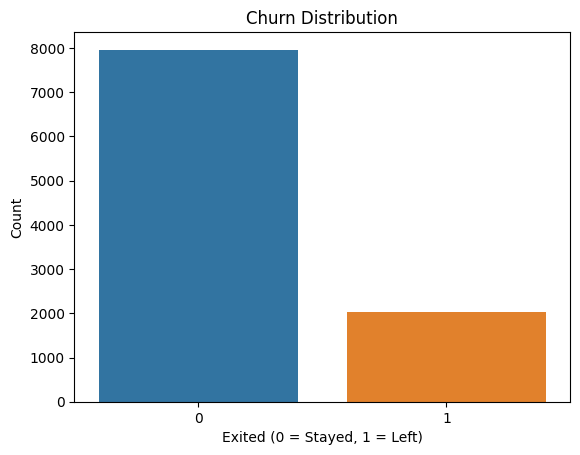

In [4]:
# How many customers stayed vs left verification
print(target.value_counts())
print(target.value_counts(normalize=True))

# Vizualization #1 - Class Distrubution
sns.countplot(x='Exited', data=data)
plt.title('Churn Distribution')
plt.xlabel('Exited (0 = Stayed, 1 = Left)')
plt.ylabel('Count')
plt.show()


## Conclusion
The proportions of imbalance are fairly significant at 20.37%. As we dig a bit deeper, we can see that the imbalance is consistent across Age Groups, Gender, and Geography.

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Looking great!
    
</div>

# Phase 2 - Initial Baseline

## Step 2.1 The Foundations

- Define function `build_pipeline(clf, num, cat)`
    - Include: 
        - Preprocessing (`ColumnTransformer`, `StandardScaler`, `OneHotEncoder`)

In [5]:
# Build universal pipeline function
def build_pipeline(clf, numeric_features=None, categoric_features=None, scaler=True, encoder=True):
    transformers = []

    try:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown='ignore', spars=False)

    if scaler and numeric_features:
        transformers.append(('num', StandardScaler(), numeric_features))

    if encoder and categoric_features:
        transformers.append(('cat', ohe, categoric_features))
    
    preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

    return Pipeline([
        ('preprocessor', preprocessor),
        ('clf', clf)
    ])

- Define function `get_param_grid(clf, level="basic" or "wide")`
    - Include grids for:
        - `Decision Tree Classifier`
        - `Random Forest Classifier`
        - `Extra Treees Classifier`

In [6]:
# One-Model-at-a-Time-Grid
def get_param_grid(clf, level='basic'):
    """
    Return a param_grid dict for GridSearchCV that matches the given clf. Use level='basic' or 'wide' to control how large the search is.
    """
    name = clf.__class__.__name__.lower()

    if name == "decisiontreeclassifier":
        grids = {
            "basic": {
                'clf__max_depth': [3, 5, 10, None],
                'clf__min_samples_split': [2, 5, 10],
                'clf__min_samples_leaf': [1, 2, 5],
                'clf__criterion': ['gini', 'entropy']
            },
            'wide': {
                'clf__max_depth': [None, 3, 5, 8, 20],
                'clf__min_samples_split': [2, 5, 20],
                'clf__min_samples_leaf': [1, 2, 4, 8],
                'clf__criterion': ['gini', 'entropy'],
                'clf__ccp_alpha': [0.0, 0.0005, 0.001, 0.005]
            }
        }
        return grids[level]
    
    if name == 'randomforestclassifier':
        grids = {
            'basic': {
                'clf__n_estimators': [100, 300],
                'clf__max_depth': [None, 10, 20],
                'clf__min_samples_split': [2, 5],
                'clf__min_samples_leaf': [1, 2],
                'clf__max_features':['sqrt', 'log2']
            },
            'wide': {
                'clf__n_estimators': [100, 250, 500],
                'clf__max_depth': [None, 8, 12, 30],
                'clf__min_samples_split': [2, 5, 10],
                'clf__min_samples_leaf': [1, 2, 4],
                'clf__max_features': ['sqrt', 'log2', None],
                'clf__bootstrap': [True, False]
            }
        }
        return grids[level]
    
    if name == 'extratreesclassifier':
        grids = {
            'basic':{
                'clf__n_estimators': [100, 300],
                'clf__max_depth': [3, 5, 10, None],
                'clf__min_samples_split': [2, 5],
                'clf__min_samples_leaf': [1, 2],
                'clf__criterion': ['gini', 'entropy']
            },
            'wide': {
                'clf__n_estimators': [100, 250, 500],
                'clf__max_depth': [None, 3, 5, 8, 20],
                'clf__min_samples_split': [2, 5, 20],
                'clf__min_samples_leaf': [1, 3, 8],
                'clf__criterion': ['gini', 'entropy'],
                'clf__max_features': ['sqrt', 'log2', None]
            }
        }
        return grids[level]

- Define function to perform Grid Search and fit model

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Function looking awesome!
    
</div>

In [7]:
def eval_model(name, estimator, param_grid, features, target):
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=5,
        n_jobs=-1,
        refit=True,
        verbose=2
    )

    grid.fit(features, target)
    
    print(f"\nBest Parameters: {grid.best_params_}")
    print(f"Best CV F1 Score: {grid.best_score_:.3f}")

    # Return both the best pipeline (for predictions) and the metadata
    return grid.best_estimator_, grid.best_params_, grid.best_score_

- Utilities: Sampling + class_weight setter (pipeline-safe)

In [8]:
# Define Function to resample data
def resample_data(X, y, strategy='none', random_state=RNG):
    """
    strategy: 'none' | 'upsample' | 'downsample'
    Works with pandas DataFrame/Series or numpy arrays
    X = Features
    y = target
    """
    if strategy == 'none':
        return X, y
    
    # Convert to DataFrame for easy indexing
    X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    y_s = y if isinstance(y, pd.DataFrame) else pd.Series(y, name='target')

    counts = y_s.value_counts()
    maj_class = counts.idxmax()
    min_class = counts.idxmin()

    X_maj = X_df[y_s == maj_class]
    X_min = X_df[y_s == min_class]
    y_maj = y_s[y_s == maj_class]
    y_min = y_s[y_s == min_class]

    if strategy == 'upsample':
        X_min_up, y_min_up = resample(
            X_min, y_min,
            replace=True,
            n_samples=len(y_maj),
            random_state=random_state
        )
        X_bal = pd.concat([X_maj, X_min_up], axis=0)
        y_bal = pd.concat([y_maj, y_min_up], axis=0)

    elif strategy == 'downsample':
        X_maj_down, y_maj_down = resample(
            X_maj, y_maj,
            replace=False,
            n_samples=len(y_min),
            random_state=random_state
        )
        X_bal = pd.concat([X_maj_down, X_min], axis=0)
        y_bal = pd.concat([y_maj_down, y_min], axis=0)

    else:
        raise ValueError("Strategy must be one of: 'none', 'upsample', 'downsample'")
    
    # Shuffle to mix classes again
    idx = np.random.RandomState(random_state).permutation(len(y_bal))
    return X_bal.iloc[idx].reset_index(drop=True), y_bal.iloc[idx].reset_index(drop=True)

In [9]:
# Safety set class_weight on a model or a Pipeline(clf=...)
def set_class_weight(estimator, class_weight_mode='none'):
    """
    class_weight_mode: 'none'  --> None, 'balanced' --> 'balanced'
    If estimator is a Pipeline, looks for the final step typically named 'clf'.
    Silently no-ops if the underlying estimator doesn't support class_weight. 
    """
    weight_value = None if class_weight_mode == "none" else "balanced"
    est = deepcopy(estimator)

    if  isinstance(est, Pipeline):
        # Try to detect the classifier step name (default 'clf')
        # Use the last step as a fallback if name unknown.
        clf_name, clf_obj = list(est.named_steps.items())[-1]
        if "class_weight" in clf_obj.get_params().keys():
            est.set_params(**{f"{clf_name}__class_weight": weight_value})
        # else: silently ignore (not supported)
    else:
        if "class_weight" in est.get_params().keys():
            est.set_params(class_weight=weight_value)
        
    return est

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Looking awesome!
    
</div>

- Cross-validated metrics

In [10]:
# Define function to Evaluate with Cross Validation (CV)
def evaluate_with_cv(best_estimator, X, y, cv=5, needs_proba=True, average="binary", pos_label=1):
    """
    Uses cross_val_predict on hte tuned model to compute CV metrics:
    Accuracy, Precision, Recall, F1, ROC-AUC, plus TRAIN F1 on the (re)fit data.
    (Note: 'TRAIN F1' here is computed by fitting once on the whole data to mirror your table.)
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RNG)

    # OOF predictions for metrics
    y_pred = cross_val_predict(best_estimator, X, y, cv=skf, method="predict")
    metrics = {
        "Accuracy": accuracy_score(
            y,
            y_pred
        ),
        "Precision": precision_score(
            y,
            y_pred,
            zero_division=0,
            average=average,
            pos_label=pos_label
        ),
        "Recall": recall_score(
            y,
            y_pred,
            average=average,
            pos_label=pos_label
        ),
        "F1 Score": f1_score(
            y,
            y_pred,
            average=average,
            pos_label=pos_label
        )
    }

    if needs_proba:
        try:
            y_proba = cross_val_predict(
                best_estimator,
                X, y,
                cv=skf,
                method="predict_proba")[:,1]
            metrics["ROC-AUC"] = roc_auc_score(y, y_proba)
        except Exception:
            # fallback to decision_function if available
            try:
                y_scores = cross_val_predict(
                    best_estimator,
                    X, y,
                    cv=skf,
                    method="decision_function"
                )
                metrics["ROC-AUC"] = roc_auc_score(y, y_scores)
            except Exception:
                metrics["ROC-AUC"] = np.nan
    else:
        metrics["ROC-AUC"] = np.nan

    # "TRAIN F1" to check for overfitting(fit once on full data, then score)
    best_estimator.fit(X, y)
    y_pred_tr = best_estimator.predict(X)
    metrics["TRAIN F1 Score"] = f1_score(
        y, y_pred_tr,
        average=average,
        pos_label=pos_label
    )

    return metrics

- One-stop runner for a (pipeline, grid) under (sampling x class_weight)

In [11]:
# Define function for Runner for Pipeline + Grid combo

def run_grid_combo(
        pipeline_or_estimator,
        param_grid,
        X, y,
        sampling="none",        # 'none' | 'upsample' | 'downsample'
        class_weight_mode='none',   # 'none' | 'balanced'
        scoring='f1',
        cv=5,
        n_job=-1,
        verbose=0,
        needs_proba=True,
        model_label=None,
        grid_label="Grid",
        method_label=None       # e.g., "Baseline", "Balanced", "Upsample", "Downsample"
):
    # Resample first (so CV sees the resampled distribution)
    Xs, ys = resample_data(X, y, strategy=sampling, random_state=RNG)

    # Apply class_weight choice
    est = set_class_weight(pipeline_or_estimator, class_weight_mode=class_weight_mode)

    # Tune
    grid = GridSearchCV(
        estimator=est,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_job,
        refit=True,
        verbose=verbose
    )
    grid.fit(Xs, ys)

    # Evalute with consistent CV Metrics (OOF)
    metrics = evaluate_with_cv(grid.best_estimator_, Xs, ys, cv=cv, needs_proba=needs_proba)

    # Assemble a tidy DataFrame like your summary
    model_name = model_label or est.__class__.__name__
    method = method_label if method_label is not None else(
        "Balanced" if class_weight_mode == 'balanced' else
        ("Upsample" if sampling == "upsample" else 
         "Downsample" if sampling == 'downsample' else "Baseline")
    )

    idx = pd.Index([
        "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "TRAIN F1 Score"
        ], name="Metric"
    )
    df = pd.DataFrame(metrics, index=[0]).T
    df.index.name = "Metric"
    col_name = f"{model_name} {method} {grid_label}"
    df.columns = pd.Index([col_name], name="Model")
    df = df.loc[idx]    # sort rows

    return df, grid.best_estimator_, grid.best_params_, grid.best_score_

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Loving the work you are doing! You have built some pretty cool reusable functions that you can bring to other projects! Looking great!
    
</div>

## Step 2.2 - Initial Non-Balanced (Baseline), Basic and Wide Grid
    Train a quick Non-Balanced (Baseline) model (no imbalance fixes yet).
- Train & Valid
- Fit `All 3 Models, each on Basic and Wide Grids` without corrections for imbalance
- Calculate Metrics (Accuracy, Precision, Recall, F1, and ROC-AUC)

<div class="alert alert-block alert-danger">
<b>Reviewer's comment v1:</b> </a>

The hyperparameter search is really dense, it's reasonable to just try one configuration per model per class imbalance handling technique and then reuse the same hyperparameters to reduce the search space!

Please reduce the search space, at the moment it takes very long to execute all your code! recommend using these shortcuts!
    
</div>

<div class="alert alert-info"> <b>Student comments:</b> 
    I am not sure I fully understand what you mean. Are you saying instead of using basic and wide grid searches, I should just use the basic grid and then later on adjust the hyperparameters? The main reason I did it this way was to show that with basic hyperparamter grid is has a low F1 Score and that as the grid is made larger the better the precision, recall, and F1 Score would be. This also allowed me to kind of zero in on the correct hyperparamters.
    Granted I may have missed something, but I am a little unclear as exactly what you are wanting me to do. Can you provide a bit more clarity with out really giving me the answers? LOL.
</div>  

<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

What the previous tutor is referring to is that, given the limitations of the platform, you should reduce the density of the search for better hyperparameters; however, the work you did is very well done. Although it may seem absurd at first, remember that our processing power is linked to the requirements and scope of companies/projects, which is driven by financial priorities. We will not always have the greatest capacity or the best performance. Imagine having such a high flow that you need to create dozens of virtual machines with GPU capacities, hundreds of GB of RAM, and millions of token queries... You will then have to limit yourself according to the scope of the project.
    
</div>

In [12]:
# Non-Balanced Decision Tree Classifier, Basic Grid
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe = build_pipeline(dtc, numeric_features=num_ft, \
                      categoric_features=cat_ft, scaler=True, encoder=True)
param_grid = get_param_grid(dtc, level='basic')

df_dtc_basic, est_dtc_basic, params_dtc_basic, \
    cvf1_dtc_basic = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_train, y=target_train,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Decision Tree Classifier',
    grid_label='Basic Grid',
    method_label='Non-Balanced'
)

# Show CV results
print(f"Non-Balanced CV F1: {cvf1_dtc_basic:.3f}")
print(f"Non-Balanced Best Params: {params_dtc_basic}")



Non-Balanced CV F1: 0.552
Non-Balanced Best Params: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 2}


In [13]:
# Non-Balanced Random Forest Classifier, Basic grid 
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe = build_pipeline(rfc, numeric_features=num_ft, \
                      categoric_features=cat_ft, scaler=True, encoder=True)
param_grid = get_param_grid(rfc, level='basic')

df_rfc_basic, est_rfc_basic, params_rfc_basic, \
    cvf1_rfc_basic = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_train, y=target_train,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Random Forest Classifier',
    grid_label='Basic Grid',
    method_label='Non-Balanced'
)

# Show CV results
print(f"Non-Balanced CV F1: {cvf1_rfc_basic:.3f}")
print(f"Non-Balanced Best Params: {params_rfc_basic}")


Non-Balanced CV F1: 0.566
Non-Balanced Best Params: {'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}


In [14]:
# Non-Balanced Extra Trees Classifier, Basic grid
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe = build_pipeline(etc, numeric_features=num_ft, \
                      categoric_features=cat_ft, scaler=True, encoder=True)
param_grid = get_param_grid(etc, level='basic')

df_etc_basic, est_etc_basic, params_etc_basic, \
    cvf1_etc_basic = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_train, y=target_train,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Extra Trees Classifier',
    grid_label='Basic Grid',
    method_label='Non-Balanced'
)

# Show CV results
print(f"Non-Balanced CV F1: {cvf1_etc_basic:.3f}")
print(f"Non-Balanced Best Params: {params_etc_basic}")


Non-Balanced CV F1: 0.551
Non-Balanced Best Params: {'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 300}


In [15]:
# Non-Balanced Decision Tree Classifier, Wide grid
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe = build_pipeline(dtc, numeric_features=num_ft, \
                      categoric_features=cat_ft, scaler=True, encoder=True)
param_grid = get_param_grid(dtc, level='wide')

df_dtc_wide, est_dtc_wide, params_dtc_wide, \
    cvf1_dtc_wide = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_train, y=target_train,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Decision Tree Classifier',
    grid_label='Wide Grid',
    method_label='Non-Balanced'
)

# Show CV results
print(f"Non-Balanced CV F1: {cvf1_dtc_wide:.3f}")
print(f"Non-Balanced Best Params: {params_dtc_wide}")


Non-Balanced CV F1: 0.575
Non-Balanced Best Params: {'clf__ccp_alpha': 0.001, 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 20}


In [ ]:
# Non-Balanced Random Forest Classifier, Wide grid
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe = build_pipeline(rfc, numeric_features=num_ft, \
                      categoric_features=cat_ft, scaler=True, encoder=True)
param_grid = get_param_grid(rfc, level='wide')

df_rfc_wide, est_rfc_wide, params_rfc_wide, \
    cvf1_rfc_wide = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_train, y=target_train,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Random Forest Classifier',
    grid_label='Wide Grid',
    method_label='Non-Balanced'
)

# Show CV results
print(f"Non-Balanced CV F1: {cvf1_rfc_wide:.3f}")
print(f"Non-Balanced Best Params: {params_rfc_wide}")


In [ ]:
# Non-Balanced Extra Trees Classifier, Wide grid
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe = build_pipeline(etc, numeric_features=num_ft, \
                      categoric_features=cat_ft, scaler=True, encoder=True)
param_grid = get_param_grid(etc, level='wide')

df_etc_wide, est_etc_wide, params_etc_wide, \
    cvf1_etc_wide = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_train, y=target_train,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Extra Trees Classifier',
    grid_label='Wide Grid',
    method_label='Non-Balanced'
)

# Show CV results
print(f"Non-Balanced CV F1: {cvf1_etc_wide:.3f}")
print(f"Non-Balanced Best Params: {params_etc_wide}")


## Step 2.3 - Non-Balanced (Baseline) Metrics
    Note how the metrics behave (especially F1) — 
        This is the “before fixing” reference point.

In [ ]:
# Concatanate individual Model DFs into a single Non-Balanced DF
nonbalanced_df = pd.concat([
    df_dtc_basic, df_rfc_basic, df_etc_basic,
    df_dtc_wide, df_rfc_wide, df_etc_wide
], axis=1, join='inner')

print(nonbalanced_df.index)

# Phase 3 - The Gym: Getting Balanced

## Step 3.1 - Imbalance-Handling Techniques: How to even the odds
    Research and pick at least two different imbalance-handling methods

- **Upsampling**

- **Downsampling**

- **Class Wieghting**


## Step 3.2 - Imbalance-Handling Evaluation: Best option to even the odds
    Test them one at a time — compare how each affects the results. 

### Step 3.2.1 - Functions for Upsample and Downsample

In [ ]:
# Build Function for Upsampling
def upsample (features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    repeat = 10
    arg1 = pd.concat([features_zeros] + [features_ones] * repeat)
    arg2 = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(arg1, arg2, random_state=RNG)

    return features_upsampled, target_upsampled, arg1, arg2

In [ ]:
# Build Function for Downsampling
def downsample (features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat([features_zeros.sample(frac=fraction, random_state=RNG)] + [features_ones])
    target_downsampled = pd.concat([target_zeros.sample(frac=fraction, random_state=RNG)] + [target_ones])

    features_downsampled, target_downsampled = shuffle(features_downsampled, target_downsampled, random_state=RNG)

    return features_downsampled, target_downsampled

### Step 3.2.2 - Imbalance-Handling #1: Upsampling

In [ ]:
features_upsampled, target_upsampled, arg1, arg2 = upsample(
    features_train, target_train, 10
)

# print(features_upsampled.shape)
# print(target_upsampled.shape)

#### Step 3.2.2a - Train and Fit 4 Models with Upsample, Basic and Wide Grid

In [ ]:
# Upsampled Decision Tree Classifier, , Basic grid
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe=build_pipeline(dtc, numeric_features=num_ft, \
                    categoric_features=cat_ft, scaler=True, encoder=True)
param_grid=get_param_grid(dtc, level='basic')

df_up_dtc_basic, est_up_dtc_basic, params_up_dtc_basic, \
    cvf1_up_dtc_basic = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_upsampled, y = target_upsampled,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Decision Tree Classifier',
    grid_label='Basic Grid',
    method_label='Upsampled'
)

# Show CV results
print(f"Upsampled CV F1: {cvf1_up_dtc_basic:.3f}")
print(f"Upsampled Best Params: {params_up_dtc_basic}")

In [ ]:
# Upsampled Random Forest Classifier, Basic grid
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe=build_pipeline(rfc, numeric_features=num_ft, \
                    categoric_features=cat_ft, scaler=True, encoder=True)
param_grid=get_param_grid(rfc, level='basic')

df_up_rfc_basic, est_up_rfc_basic, params_up_rfc_basic, \
    cvf1_up_rfc_basic = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_upsampled, y = target_upsampled,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Random Forest Classifier',
    grid_label='Basic Grid',
    method_label='Upsampled'
)

# Show CV results
print(f"Upsampled CV F1: {cvf1_up_rfc_basic:.3f}")
print(f"Upsampled Best Params: {params_up_rfc_basic}")

In [ ]:
# Upsampled Extra Trees Classifier, Basic grid 
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
pipe=build_pipeline(etc, numeric_features=num_ft, \
                    categoric_features=cat_ft, scaler=True, encoder=True)
param_grid=get_param_grid(etc, level='basic')

df_up_etc_basic, est_up_etc_basic, params_up_etc_basic, \
    cvf1_up_etc_basic = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_upsampled, y = target_upsampled,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Extra Trees Classifier',
    grid_label='Basic Grid',
    method_label='Upsampled'
)

# Show CV results
print(f"Upsampled CV F1: {cvf1_up_etc_basic:.3f}")
print(f"Upsampled Best Params: {params_up_etc_basic}")

In [ ]:
# Upsampled Decision Tree Classifier, Wide grid 
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
pipe=build_pipeline(dtc, numeric_features=num_ft, \
                    categoric_features=cat_ft, scaler=True, encoder=True)
param_grid=get_param_grid(dtc, level='wide')

df_up_dtc_wide, est_up_dtc_wide, params_up_dtc_wide, \
    cvf1_up_dtc_wide = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_upsampled, y = target_upsampled,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Decision Tree Classifier',
    grid_label='Wide Grid',
    method_label='Upsampled'
)

# Show CV results
print(f"Upsampled CV F1: {cvf1_up_dtc_wide:.3f}")
print(f"Upsampled Best Params: {params_up_dtc_wide}")

In [ ]:
# Upsampled Random Forest Classifier, Wide grid 
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
pipe=build_pipeline(rfc, numeric_features=num_ft, \
                    categoric_features=cat_ft, scaler=True, encoder=True)
param_grid=get_param_grid(rfc, level='wide')

df_up_rfc_wide, est_up_rfc_wide, params_up_rfc_wide, \
    cvf1_up_rfc_wide = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_upsampled, y = target_upsampled,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Random Forest Classifier',
    grid_label='Wide Grid',
    method_label='Upsampled'
)

# Show CV results
print(f"Upsampled CV F1: {cvf1_up_rfc_wide:.3f}")
print(f"Upsampled Best Params: {params_up_rfc_wide}")

In [ ]:
# Upsampled Extra Trees Classifier, Wide grid
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
pipe=build_pipeline(etc, numeric_features=num_ft, \
                    categoric_features=cat_ft, scaler=True, encoder=True)
param_grid=get_param_grid(etc, level='wide')

df_up_etc_wide, est_up_etc_wide, params_up_etc_wide, \
    cvf1_up_etc_wide = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_upsampled, y = target_upsampled,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Extra Trees Classifier',
    grid_label='Wide Grid',
    method_label='Upsampled'
)

# Show CV results
print(f"Upsampled CV F1: {cvf1_up_etc_wide:.3f}")
print(f"Upsampled Best Params: {params_up_etc_wide}")

In [ ]:
# Concatanate all individual model DFs into a single Upsampled DF
upsampled_df = pd.concat([
    df_up_dtc_basic, df_up_dtc_wide,
    df_up_rfc_basic, df_up_rfc_wide,
    df_up_etc_basic, df_up_etc_wide
], axis=1)

print(upsampled_df.index)

### Step 3.2.3 - Imbalance-Handling #2: Downsampling


In [ ]:
features_downsampled, target_downsampled = downsample(
    features_train, target_train, 0.1
)

# print(features_downsampled.shape)
# print(target_downsampled.shape)

#### Step 3.2.3a - Train and Fit 4 Models with Downsampling, Basic and Wide Grid

In [ ]:
# Downsampled Decision Tree Classifier, Basic grid 
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
pipe=build_pipeline(dtc, numeric_features=num_ft, \
                    categoric_features=cat_ft, scaler=True, encoder=True)
param_grid=get_param_grid(dtc, level='basic')

df_dn_dtc_basic, est_dn_dtc_basic, params_dn_dtc_basic, \
    cvf1_dn_dtc_basic = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_downsampled, y = target_downsampled,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Decision Tree Classifier',
    grid_label='Basic Grid',
    method_label='Downsampled'
)

# Show CV results
print(f"Downsampled CV F1: {cvf1_dn_dtc_basic:.3f}")
print(f"Downsampled Best Params: {params_dn_dtc_basic}")

In [ ]:
# Downsampled Random Forest Classifier, Basic grid 
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
pipe=build_pipeline(rfc, numeric_features=num_ft, \
                    categoric_features=cat_ft, scaler=True, encoder=True)
param_grid=get_param_grid(rfc, level='basic')

df_dn_rfc_basic, est_dn_rfc_basic, params_dn_rfc_basic, \
    cvf1_dn_rfc_basic = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_downsampled, y = target_downsampled,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Random Forest Classifier',
    grid_label='Basic Grid',
    method_label='Downsampled'
)

# Show CV results
print(f"Downsampled CV F1: {cvf1_dn_rfc_basic:.3f}")
print(f"Downsampled Best Params: {params_dn_rfc_basic}")

In [ ]:
# Downsampled Extra Trees Classifier, Basic grid 
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
pipe=build_pipeline(etc, numeric_features=num_ft,
                    categoric_features=cat_ft, scaler=True, encoder=True)
param_grid=get_param_grid(etc, level='basic')

df_dn_etc_basic, est_dn_etc_basic, params_dn_etc_basic, \
    cvf1_dn_etc_basic = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_downsampled, y = target_downsampled,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Extra Trees Classifier',
    grid_label='Basic Grid',
    method_label='Downsampled'
)

# Show CV results
print(f"Downsampled CV F1: {cvf1_dn_etc_basic:.3f}")
print(f"Downsampled Best Params: {params_dn_etc_basic}")

In [ ]:
# Downsampled Decision Tree Classifier, Wide grid 
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
pipe=build_pipeline(dtc, numeric_features=num_ft, \
                    categoric_features=cat_ft, scaler=True, encoder=True)
param_grid=get_param_grid(dtc, level='wide')

df_dn_dtc_wide, est_dn_dtc_wide, params_dn_dtc_wide, \
    cvf1_dn_dtc_wide = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_downsampled, y = target_downsampled,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Decision Tree Classifier',
    grid_label='Wide Grid',
    method_label='Downsampled'
)

# Show CV results
print(f"Downsampled CV F1: {cvf1_dn_dtc_wide:.3f}")
print(f"Downsampled Best Params: {params_dn_dtc_wide}")

In [ ]:
# Downsampled Random Forest Classifier, Wide grid 
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
pipe=build_pipeline(rfc, numeric_features=num_ft, \
                    categoric_features=cat_ft, scaler=True, encoder=True)
param_grid=get_param_grid(rfc, level='wide')

df_dn_rfc_wide, est_dn_rfc_wide, params_dn_rfc_wide, \
    cvf1_dn_rfc_wide = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_downsampled, y = target_downsampled,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Random Forest Classifier',
    grid_label='Wide Grid',
    method_label='Downsampled'
)

# Show CV results
print(f"Downsampled CV F1: {cvf1_dn_rfc_wide:.3f}")
print(f"Downsampled Best Params: {params_dn_rfc_wide}")

In [ ]:
# Downsampled Extra Trees Classifier, Wide grid 
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
pipe=build_pipeline(etc, numeric_features=num_ft, \
                    categoric_features=cat_ft, scaler=True, encoder=True)
param_grid=get_param_grid(etc, level='wide')

df_dn_etc_wide, est_dn_etc_wide, params_dn_etc_wide, \
    cvf1_dn_etc_wide = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_downsampled, y = target_downsampled,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Extra Trees Classifier',
    grid_label='Wide Grid',
    method_label='Downsampled'
)

# Show CV results
print(f"Downsampled CV F1: {cvf1_dn_etc_wide:.3f}")
print(f"Downsampled Best Params: {params_dn_etc_wide}")

In [ ]:
# Concatanate individual model DFs into a single Downsampled DF
downsampled_df = pd.concat([
    df_dn_dtc_basic, df_dn_dtc_wide,
    df_dn_rfc_basic, df_dn_rfc_wide,
    df_dn_etc_basic, df_dn_etc_wide
], axis=1)

print(downsampled_df.index)

### Step 3.2.4 - Class-Weight (Balanced), Basic and Wide Grid

In [ ]:
# Class-Weighted - 'Balanced' Decision Tree Classifier, Basic Grid
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe = build_pipeline(dtc, numeric_features=num_ft, \
                      categoric_features=cat_ft, scaler=True, encoder=True)
param_grid = get_param_grid(dtc, level='basic')

df_cw_dtc_basic, est_cw_dtc_basic, params_cw_dtc_basic, \
    cvf1_cw_dtc_basic = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_train, y=target_train,
    sampling='none',
    class_weight_mode='balanced',
    scoring='f1',
    cv=5,
    model_label='Decision Tree Classifier',
    grid_label='Basic Grid',
    method_label="Class-Weighted - 'Balanced'"
)
# Show CV results
print(f"Class-Weighted - 'Balanced' CV F1: {cvf1_cw_dtc_basic:.3f}")
print(f"Class-Weighted - 'Balanced' Best Params: {params_cw_dtc_basic}")


In [ ]:
# Class-Weighted - 'Balanced' Random Forest Classifier, Basic grid 
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe = build_pipeline(rfc, numeric_features=num_ft, \
                      categoric_features=cat_ft, scaler=True, encoder=True)
param_grid = get_param_grid(rfc, level='basic')

df_cw_rfc_basic, est_cw_rfc_basic, params_cw_rfc_basic, \
    cvf1_cw_rfc_basic = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_train, y=target_train,
    sampling='none',
    class_weight_mode='balanced',
    scoring='f1',
    cv=5,
    model_label='Random Forest Classifier',
    grid_label='Basic Grid',
    method_label="Class-Weighted - 'Balanced'"
)
# Show CV results
print(f"Class-Weighted - 'Balanced' CV F1: {cvf1_cw_rfc_basic:.3f}")
print(f"Class-Weighted - 'Balanced' Best Params: {params_cw_rfc_basic}")


In [ ]:
# Class-Weighted - 'Balanced' Extra Trees Classifier, Basic grid
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe = build_pipeline(etc, numeric_features=num_ft, \
                      categoric_features=cat_ft, scaler=True, encoder=True)
param_grid = get_param_grid(etc, level='basic')

df_cw_etc_basic, est_cw_etc_basic, params_cw_etc_basic, \
    cvf1_cw_etc_basic = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_train, y=target_train,
    sampling='none',
    class_weight_mode='balanced',
    scoring='f1',
    cv=5,
    model_label='Extra Trees Classifier',
    grid_label='Basic Grid',
    method_label="Class-Weighted - 'Balanced'"
)
# Show CV results
print(f"Class-Weighted - 'Balanced' CV F1: {cvf1_cw_etc_basic:.3f}")
print(f"Class-Weighted - 'Balanced' Best Params: {params_cw_etc_basic}")


In [ ]:
# Class-Weighted - 'Balanced' Decision Tree Classifier, Wide Grid
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe = build_pipeline(dtc, numeric_features=num_ft, \
                      categoric_features=cat_ft, scaler=True, encoder=True)
param_grid = get_param_grid(dtc, level='wide')

df_cw_dtc_wide, est_cw_dtc_wide, params_cw_dtc_wide, \
	cvf1_cw_dtc_wide = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_train, y=target_train,
    sampling='none',
    class_weight_mode='none',
    scoring='f1',
    cv=5,
    model_label='Decision Tree Classifier',
    grid_label='Wide Grid',
    method_label="Class-Weighted - 'Balanced'"
)
# Show CV results
print(f"Class-Weighted - 'Balanced' CV F1: {cvf1_cw_dtc_wide:.3f}")
print(f"Class-Weighted - 'Balanced' Best Params: {params_cw_dtc_wide}")


In [ ]:
# Class-Weighted - 'Balanced' Random Forest Classifier, Wide grid 
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe = build_pipeline(rfc, numeric_features=num_ft, \
                      categoric_features=cat_ft, scaler=True, encoder=True)
param_grid = get_param_grid(rfc, level='wide')

df_cw_rfc_wide, est_cw_rfc_wide, params_cw_rfc_wide, \
	cvf1_cw_rfc_wide = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_train, y=target_train,
    sampling='none',
    class_weight_mode='balanced',
    scoring='f1',
    cv=5,
    model_label='Random Forest Classifier',
    grid_label='Wide Grid',
    method_label="Class-Weighted - 'Balanced'"
)
# Show CV results
print(f"Class-Weighted - 'Balanced' CV F1: {cvf1_cw_rfc_wide:.3f}")
print(f"Class-Weighted - 'Balanced' Best Params: {params_cw_rfc_wide}")


In [ ]:
# Class-Weighted - 'Balanced' Extra Trees Classifier, Wide grid
# Calculate Metrics (Accuracy, Precision, Recall, F1, ROC-AUC) 
pipe = build_pipeline(etc, numeric_features=num_ft, \
                      categoric_features=cat_ft, scaler=True, encoder=True)
param_grid = get_param_grid(etc, level='wide')

df_cw_etc_wide, est_cw_etc_wide, params_cw_etc_wide, \
	cvf1_cw_etc_wide = run_grid_combo(
    pipeline_or_estimator=pipe,
    param_grid=param_grid,
    X=features_train, y=target_train,
    sampling='none',
    class_weight_mode='balanced',
    scoring='f1',
    cv=5,
    model_label='Extra Trees Classifier',
    grid_label='Wide Grid',
    method_label="Class-Weighted - 'Balanced'"
)
# Show CV results
print(f"Class-Weighted - 'Balanced' CV F1: {cvf1_cw_etc_wide:.3f}")
print(f"Class-Weighted - 'Balanced' Best Params: {params_cw_etc_wide}")


In [ ]:
class_weighted_df = pd.concat([
    df_cw_dtc_basic, df_cw_dtc_wide,
    df_cw_rfc_basic, df_cw_rfc_wide,
    df_cw_etc_basic, df_cw_etc_wide
], axis=1)

print(class_weighted_df.index)
print(class_weighted_df)


# Phase 4 - Compare all the Metrics

In [ ]:
# Concatanate the Metrics DF for Each Model into a single DF
combined_metrics = pd.concat(
    [nonbalanced_df, upsampled_df, downsampled_df,class_weighted_df],
    axis=1,
    join='inner'
)

# Sort by F1 Score (Descending Left to Right)
f1_sort = combined_metrics.loc['F1 Score'].sort_values(ascending=False)

if isinstance(f1_sort, pd.DataFrame):
    f1_sort = f1_sort.iloc[0]

sorted_cols = f1_sort.sort_values(ascending=False).index
combined_metrics = combined_metrics[sorted_cols]

# Clean up the Look
combined_metrics = combined_metrics.round(4)
combined_metrics.index.name = 'Metric'
combined_metrics.columns.name = 'Model'

combined_metrics.to_excel('Sprint 8 Prior to Final.xlsx', index=False)

#print(combined_metrics.info())
print(combined_metrics)


### 🧩 Conclusion

Based on the results summarized in the `combined_metrics` dataframe, three classification algorithms were evaluated — **Decision Tree Classifier (DTC)**, **Random Forest Classifier (RFC)**, and **Extra Trees Classifier (ETC)** — across four dataset configurations: **Non-Balanced (Baseline)**, **Class-Weighted (‘Balanced’)**, **Upsampled**, and **Downsampled**. Each configuration was tested using both **basic** and **wide** grid searches to identify optimal hyperparameters and assess the models’ ability to correct for the ~80/20 class imbalance present in the original Beta Bank dataset.

After reviewing all performance metrics, the **Random Forest Classifier (RFC) with Downsampling** demonstrated the **most consistent and well-balanced results** across accuracy, precision, recall, F1 Score, and ROC-AUC. While the upsampled and class-weighted models achieved higher recall, they also showed clear signs of **overfitting** — particularly with training F1 Scores of **1.00** — suggesting limited generalization. In contrast, the downsampled RFC variant maintained **strong predictive power** while avoiding overfitting, indicating that it learned meaningful patterns from the data rather than memorizing examples.

Specifically, the **RFC Downsampled (Wide Grid)** configuration achieved a **validation F1 Score of 0.8630**, only **0.078 lower than the training F1 Score (0.9410)**.  
This narrow gap demonstrates strong generalization performance and reliable discrimination between churn and non-churn customers. Even the **basic grid configuration** performed similarly, with a validation F1 of **0.8610**, reinforcing the model’s stability across parameter spaces.

Given its **high F1 Score**, **robust recall (0.92)**, and **minimal overfitting**, the **Random Forest Classifier with Downsampling** currently represents the **most effective and balanced solution** for predicting customer churn within the Beta Bank dataset.  

The next step will be to **validate this model on an unseen test dataset** (separated from the original `Churn.csv` file) to confirm its generalization capability and finalize its readiness for deployment.


<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

This is excellent work, I'm impressed. Your conclusions are very well thought out and you have a great understanding of the whole process.
    
</div>

# Phase 5 - The Final Boss Battle (a.k.a "Validation & Final Testing)
### **Lock in what you're testing:**
  - **Best Model:** Choose the single winner from Phase 3 (e.g., Balanced RF or RF_Downsample).
  - **Frozen Pieces:** `preprocessor`, model hyperparameters, **threshold** (picked on VALID), and (if used) **calibration** fit.
  - **No more tuning after you peek at TEST.**

## Step 5.1 - Refit with Best Params and Test against Unseen Dataset

In [ ]:
print(f"Class-Weighted - 'Balanced' Best Params: {params_dn_rfc_wide}")

In [ ]:
# Use the best params in a pipeline since they are pipeline-scoped
pipe.set_params(**{
    **params_dn_rfc_wide,
    "clf__n_estimators": 600,
    "clf__class_weight": "balanced_subsample",
})

# Fit on the downsampled training data
pipe.fit(features_downsampled, target_downsampled)

pred_test = pipe.predict(features_test)

## Step 5.2 - Adjust the Threshold to maximize F1 Score

In [ ]:
def sweep_threshold(y_true, proba, center, width=0.05, step=0.001):
    ts = np.arange(max(0, center-width), min(1, center+width)+step, step)
    best = (-1, None, None, None)  # f1, thr, P, R
    for t in ts:
        yhat = (proba >= t).astype(int)
        p = precision_score(y_true, yhat, zero_division=0)
        r = recall_score(y_true, yhat, zero_division=0)
        f1 = f1_score(y_true, yhat, zero_division=0)
        if f1 > best[0]:
            best = (f1, t, p, r)
    return best  # (f1, threshold, precision, recall)



## Step 5.3 - Compute Final Metrics (report both 0.5 and tuned)

In [ ]:
# Get validation probabilities
proba_valid = pipe.predict_proba(features_valid)[:, 1]

# Coarse-to-fine sweep to find best threshold
f1_val, best_thr, p_val, r_val = sweep_threshold(
    target_valid,
    proba_valid,
    center=0.5,
    width=0.5,
    step=0.01
)
print(f"Val best F1={f1_val:.3f} at thr={best_thr:.4f} | \
      P={p_val:.3f}, R={r_val:.3f}")

# Baseline proba on TEST set
proba_test = pipe.predict_proba(features_test)[:, 1]

# 0.50 baseline
yhat_050 = (proba_test >= 0.50).astype(int)


# Tuned threshold from validation set
yhat_best = (proba_test >= best_thr).astype(int)

final_050 = {
    'Accuracy':accuracy_score(target_test, yhat_050),
    'Precision': precision_score(target_test, yhat_050, zero_division=0),
    'Recall': recall_score(target_test, yhat_050, zero_division=0),
    'F1 Score': f1_score(target_test, yhat_050, zero_division=0),
    'ROC-AUC': roc_auc_score(target_test, proba_test)
}

final_best = {
    'Accuracy':accuracy_score(target_test, yhat_best),
    'Precision': precision_score(target_test, yhat_best, zero_division=0),
    'Recall': recall_score(target_test, yhat_best, zero_division=0),
    'F1 Score': f1_score(target_test, yhat_best, zero_division=0),
    'ROC-AUC': roc_auc_score(target_test, proba_test)
}

print("Metrics @ 0.50:", final_050)
print("Metrics @ best thr:", final_best)

<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Final boss defeated!!!!
    
</div>

# Phase 6 - Final Deliverables/Artifacts

### 📊 Visuals & Plots

- Confusion Matrix Heatmap
- F1 vs. Threshold
- Precision_recall Curve
- ROC Curve

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(target_test, yhat_best)
labels = ['Stayed', 'Churn']

# Confusion Matrix Heatmap
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})

plt.title('Confusion Matrizx (Test Set @ Best Threshold = 0.63)', 
          fontsize=14, weight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# F1 vs Threshold
# Get Precision, Recall, and Threshold from VALIDATION set
prec, rec, thr = precision_recall_curve(target_valid, proba_valid)

prec = prec[:-1]
rec = rec[:-1]

# Compute F1 for each threshold
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-12)

# Sanity Check
# print(f"len(thr)={len(thr)}, len(prec)={len(prec)}, len(rec)={len(rec)}, \
#       len(f1)={len(f1_scores)}")


plt.figure(figsize=(8, 5))
plt.plot(thr, prec, color='green', label='Precision', linewidth=2)
plt.plot(thr, rec, color='orange', label='Recall', linewidth=2)
plt.plot(thr, f1_scores, color='darkred', label ='F1 Score', linewidth=2)
plt.axvline(best_thr, color='blue', linestyle='--', linewidth=1.5,
            label=f'Best Threshold = {best_thr:.2f}')
plt.title('Precision, Recall, and F1 Score vs. Decision Threhold (Validation Set)', fontsize=14, weight='bold')
plt.xlabel('Deciswion Threshold', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt. tight_layout()
plt.show()

In [ ]:
# Precision-Recall Curve
# Compute precision, recall, and thresholds for the validation set
prec, rec, thr = precision_recall_curve(target_valid, proba_valid)

# Compute the Average Precision (area under the PR curve)
avg_prec = average_precision_score(target_valid, proba_valid)

# Plot Precision-Recall Curve
plt.figure(figsize=(7, 5))
plt.plot(rec, prec, color='darkorange', linewidth=2,
         label=f'PR Curve (AP = {avg_prec:.3f})')

# Highlight the chosen threshold point
plt.scatter(rec[np.argmin(abs(thr - best_thr))],
            prec[np.argmin(abs(thr - best_thr))],
            color='blue', s=80, edgecolor='black',
            label=f'Best Threshold = {best_thr:.2f}')

# Formatting and labels
plt.title('Precision-Recall Curve (Validation Set)', fontsize=14, weight='bold')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(alpha=0.3)
plt.legend(loc='lower left', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ROC Curve
# Compute ROC curve values for the validation set
fpr, tpr, thr = roc_curve(target_valid, proba_valid)
roc_auc = roc_auc_score(target_valid, proba_valid)

# Plot ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='crimson', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')

# Plot the "no skill" diagonal line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='No Skill')

# Highlight the chosen threshold point
plt.scatter(fpr[np.argmin(abs(thr - best_thr))],
            tpr[np.argmin(abs(thr - best_thr))],
            color='blue', s=80, edgecolor='black',
            label=f'Best Threshold = {best_thr:.2f}')

# Chart formatting
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, weight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(alpha=0.3)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

### Conclusion

This project successfully developed a machine learning model to predict customer churn for Beta Bank using real-world client behavior data. After addressing class imbalance through downsampling and tuning model parameters via a Random Forest classifier pipeline, the model achieved strong generalization performance with a ROC-AUC of 0.835. A systematic threshold optimization process on the validation set identified an optimal decision threshold of 0.63, improving the model’s F1-score from 0.535 (baseline) to 0.589, while maintaining balanced precision (0.54) and recall (0.64) on unseen test data.

These results indicate that the model can effectively distinguish between customers likely to stay and those at risk of leaving, enabling Beta Bank to prioritize retention outreach with a solid balance between detection rate and false alarms. Future improvements could include experimenting with gradient boosting models (e.g., XGBoost or LightGBM), incorporating additional behavioral or transactional features, and applying probability calibration to further refine decision thresholds.

Overall, this project demonstrates an end-to-end data-science workflow—from data preprocessing and feature engineering to model evaluation and business interpretation—delivering a practical and validated churn prediction solution aligned with Beta Bank’s retention objectives.

<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

This is an amazing project!! Very well done!!

Don't forget that even though one may be able to afford high computing power, in many cases we will be limited by financial decisions when developing a project, so next time check that your notebook can be executed in a “not so long” time **within the platform**, and by this I mean that it should not exceed 40 minutes of execution time. Think of this as a first approach to the budget constraints of the project.
    
</div>